#  Feature Engineering

In this section, new features are engineered from the existing dataset to improve model performance. These features aim to capture temporal patterns, statistical trends, and contextual relationships influencing energy consumption.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


##  Time-Based Features

Time-based features help capture daily and weekly consumption patterns. These include hour of the day, day of the week, weekend indicator, and peak usage hours.

In [9]:
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Peak hours: Morning + Evening
df['is_peak_hour'] = df['hour'].isin([6,7,8,9,18,19,20,21]).astype(int)

df[['date','hour','day_of_week','is_weekend','is_peak_hour']].head()

,date,hour,day_of_week,is_weekend,is_peak_hour
0,2016-01-11 17:00:00,17,0,0,0
1,2016-01-11 17:10:00,17,0,0,0
2,2016-01-11 17:20:00,17,0,0,0
3,2016-01-11 17:30:00,17,0,0,0
4,2016-01-11 17:40:00,17,0,0,0


## Rolling Statistics

Rolling statistics help capture short-term trends and variability in energy consumption.

In [13]:
df['rolling_mean_6'] = df['Appliances'].rolling(6).mean()
df['rolling_std_6'] = df['Appliances'].rolling(6).std()

df['rolling_mean_12'] = df['Appliances'].rolling(12).mean()
df['rolling_std_12'] = df['Appliances'].rolling(12).std()

df[['Appliances','rolling_mean_6','rolling_std_6']].head(10)
#df[['Appliances','rolling_mean_12','rolling_std_12']].head(10)

,Appliances,rolling_mean_6,rolling_std_6
0,60,NaN,NaN
1,60,NaN,NaN
2,50,NaN,NaN
3,50,NaN,NaN
4,60,NaN,NaN
5,50,55.000000,5.477226
6,60,55.000000,5.477226
7,60,55.000000,5.477226
8,60,56.666667,5.163978
9,70,60.000000,6.324555


##  Lag Features

Lag features introduce past values of energy consumption to capture temporal dependencies.

In [14]:
df['lag_1'] = df['Appliances'].shift(1)
df['lag_2'] = df['Appliances'].shift(2)
df['lag_6'] = df['Appliances'].shift(6)
df['lag_12'] = df['Appliances'].shift(12)
df['lag_24'] = df['Appliances'].shift(24)
df['lag_48'] = df['Appliances'].shift(48)

df[['Appliances','lag_1','lag_2','lag_6']].head(10)

,Appliances,lag_1,lag_2,lag_6
0,60,NaN,NaN,NaN
1,60,60.0,NaN,NaN
2,50,60.0,60.0,NaN
3,50,50.0,60.0,NaN
4,60,50.0,50.0,NaN
5,50,60.0,50.0,NaN
6,60,50.0,60.0,60.0
7,60,60.0,50.0,60.0
8,60,60.0,60.0,50.0
9,70,60.0,60.0,50.0


##  Interaction Feature

The temperature difference between indoor and outdoor environments influences heating and cooling energy usage.

In [22]:
df['temp_diff'] = df['T2'] - df['T_out']

df[['T2','T_out','temp_diff']].head()

,T2,T_out,temp_diff
48,20.50,5.100000,15.400000
49,20.39,5.116667,15.273333
50,20.39,5.133333,15.256667
51,20.29,5.150000,15.140000
52,20.23,5.166667,15.063333


##  Fourier Features (Cyclical Encoding)

Time variables are cyclical in nature. Fourier transformations help encode these cyclical patterns effectively.

In [15]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df[['hour','hour_sin','hour_cos']].head()

,hour,hour_sin,hour_cos
0,17,-0.965926,-0.258819
1,17,-0.965926,-0.258819
2,17,-0.965926,-0.258819
3,17,-0.965926,-0.258819
4,17,-0.965926,-0.258819


In [24]:
# Remove rows with NaN due to rolling and lag
df = df.dropna()

df.shape

(19639, 40)

---

#  Feature Engineering — Justification Document

## Overall Philosophy

Energy consumption in residential buildings is inherently a **time-dependent, multi-variate process**. Raw sensor readings alone — such as instantaneous temperature or humidity — capture only a snapshot of the environment at a single point in time. They fail to represent the *dynamics* of how consumption evolves, the *periodicity* of human behaviour, or the *interactions* between environmental variables that truly drive appliance usage.

Our feature engineering strategy rests on **four pillars**:

1. **Temporal context** — encode *when* an observation occurs within daily and weekly cycles.
2. **Short-term memory** — give the model access to *recent history* through rolling statistics and lag values.
3. **Domain-informed interactions** — construct features that reflect known *physical relationships* (e.g., indoor vs. outdoor temperature).
4. **Cyclical encoding** — represent periodic variables without artificial discontinuities.

Together these pillars allow a downstream model to learn complex consumption patterns that would be invisible in the raw data.

---

## Feature-by-Feature Justification

### 1. Time-Based Features (`hour`, `day_of_week`, `is_weekend`, `is_peak_hour`)

| Feature | Reasoning |
|---------|-----------|
| `hour` | Energy usage follows strong **diurnal patterns** — cooking, lighting, and HVAC loads vary dramatically between morning, afternoon, and night. Extracting the hour lets the model learn these intra-day rhythms. |
| `day_of_week` | Consumption profiles differ between weekdays (occupants at work/school) and weekends/holidays (occupants at home). The day index captures this **weekly seasonality**. |
| `is_weekend` | A binary flag that simplifies the weekday-vs-weekend distinction. Many models benefit from an explicit **categorical split** rather than relying solely on the ordinal day index. |
| `is_peak_hour` | Utility grids and household routines exhibit well-documented **peak demand windows** (morning 6–9 h, evening 18–21 h). Flagging these hours gives the model a direct signal aligned with domain knowledge. |

### 2. Rolling Statistics (`rolling_mean_6/12`, `rolling_std_6/12`)

A single appliance reading is noisy. **Rolling means** over 6 and 12 time-steps (1 h and 2 h at the 10-minute sampling rate) smooth out measurement noise and reveal the **local trend** — is consumption rising, falling, or steady?

**Rolling standard deviations** over the same windows quantify **local volatility**. High volatility may indicate intermittent high-power appliances (ovens, washing machines) cycling on and off, which is predictive of near-future spikes.

Two window sizes (6 and 12) are chosen to capture both *very short-term* and *medium-term* dynamics without introducing excessive multicollinearity.

### 3. Lag Features (`lag_1` through `lag_48`)

Energy consumption is **auto-correlated**: the best predictor of current usage is often *recent past usage*. Lag features make this temporal dependency explicit.

| Lag | Time Offset | Rationale |
|-----|-------------|-----------|
| `lag_1` | 10 min | Captures the **immediate momentum** of consumption. |
| `lag_2` | 20 min | Adds a second short-term memory point to help distinguish transients from sustained loads. |
| `lag_6` | 1 h | Aligns with **hourly behavioural cycles** (e.g., a cooking session that started an hour ago). |
| `lag_12` | 2 h | Captures **medium-range** dependencies. |
| `lag_24` | 4 h | Spans roughly a quarter of the day — useful for catching **half-day patterns**. |
| `lag_48` | 8 h | Covers a full working/sleeping shift, linking current usage to the **same phase of the previous cycle**. |

Multiple lags at geometrically increasing intervals give the model a rich *temporal receptive field* without an explosion in feature count.

### 4. Interaction Feature (`temp_diff`)

The difference `T2 - T_out` (indoor dining-room temperature minus outdoor temperature) is a direct proxy for the **thermal load on the building envelope**. When the gap is large and positive, heating systems must work harder; when it is negative (hot weather), cooling loads rise. This single feature encodes a **physically meaningful interaction** that would otherwise require the model to learn implicitly from two separate columns.

### 5. Fourier / Cyclical Encoding (`hour_sin`, `hour_cos`, `day_sin`, `day_cos`)

Representing *hour = 0* and *hour = 23* as integers 0 and 23 misleads distance-based and gradient-based models into thinking these two points are far apart, when in reality they are **neighbours on a circle**.

Mapping each periodic variable to a **(sin, cos) pair** preserves the true circular geometry. The Euclidean distance between any two encoded points now faithfully reflects their **angular separation**, eliminating edge-of-period artefacts.

### 6. Dropping NaN Rows

Rolling and lag operations introduce **leading NaN values** (up to 48 rows for `lag_48`). Rather than impute these with potentially misleading values, we drop them outright — the loss of approximately 48 rows out of 19,735 (less than 0.25%) is negligible and keeps the dataset **clean and unbiased**.

---

## Summary

| Category | Features | Count |
|----------|----------|-------|
| Time-based | `hour`, `day_of_week`, `is_weekend`, `is_peak_hour` | 4 |
| Rolling statistics | `rolling_mean_6`, `rolling_std_6`, `rolling_mean_12`, `rolling_std_12` | 4 |
| Lag values | `lag_1`, `lag_2`, `lag_6`, `lag_12`, `lag_24`, `lag_48` | 6 |
| Interaction | `temp_diff` | 1 |
| Cyclical encoding | `hour_sin`, `hour_cos`, `day_sin`, `day_cos` | 4 |
| **Total new features** | | **19** |

These 19 engineered features complement the original 27 sensor columns to give the model a comprehensive view of temporal patterns, recent consumption history, environmental context, and cyclical rhythms — all grounded in domain knowledge of residential energy systems.


#  Correlation and Mutual Information Analysis

In this section, we analyze the relationship between input features and the target variable (`Appliances`) using two methods:

- **Correlation Analysis** (Linear relationships)
- **Mutual Information Analysis** (Non-linear dependencies)

This helps identify the most important features for predicting energy consumption.

In [25]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])

df_numeric.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,rolling_std_6,rolling_mean_12,rolling_std_12,lag_1,lag_2,lag_6,lag_12,lag_24,lag_48,temp_diff
96,50,0,19.856667,47.063333,19.000000,45.030000,20.100000,45.200000,19.100000,45.230000,...,23.166067,72.500000,27.344602,60.0,60.0,140.0,40.0,50.0,380.0,14.200000
97,60,0,19.790000,46.656667,19.000000,44.966667,20.100000,45.163333,19.100000,45.090000,...,13.662601,73.333333,26.742317,50.0,60.0,110.0,50.0,50.0,370.0,14.116667
98,50,0,19.790000,46.333333,19.000000,44.826667,20.100000,45.090000,19.100000,44.966667,...,5.163978,72.500000,27.344602,60.0,50.0,90.0,60.0,40.0,120.0,14.033333
99,30,0,19.790000,46.066667,19.000000,44.645000,20.100000,45.163333,19.033333,44.766667,...,11.690452,70.000000,29.848100,50.0,60.0,60.0,60.0,40.0,50.0,13.950000
100,40,0,19.760000,45.863333,18.963333,44.560000,20.033333,44.963333,19.000000,44.663333,...,11.690452,67.500000,31.079078,30.0,50.0,60.0,70.0,40.0,40.0,13.830000


##  Correlation Analysis

Correlation measures the **linear relationship** between variables. Values range from:

- +1 → Strong positive relationship  
-  0 → No relationship  
- -1 → Strong negative relationship  

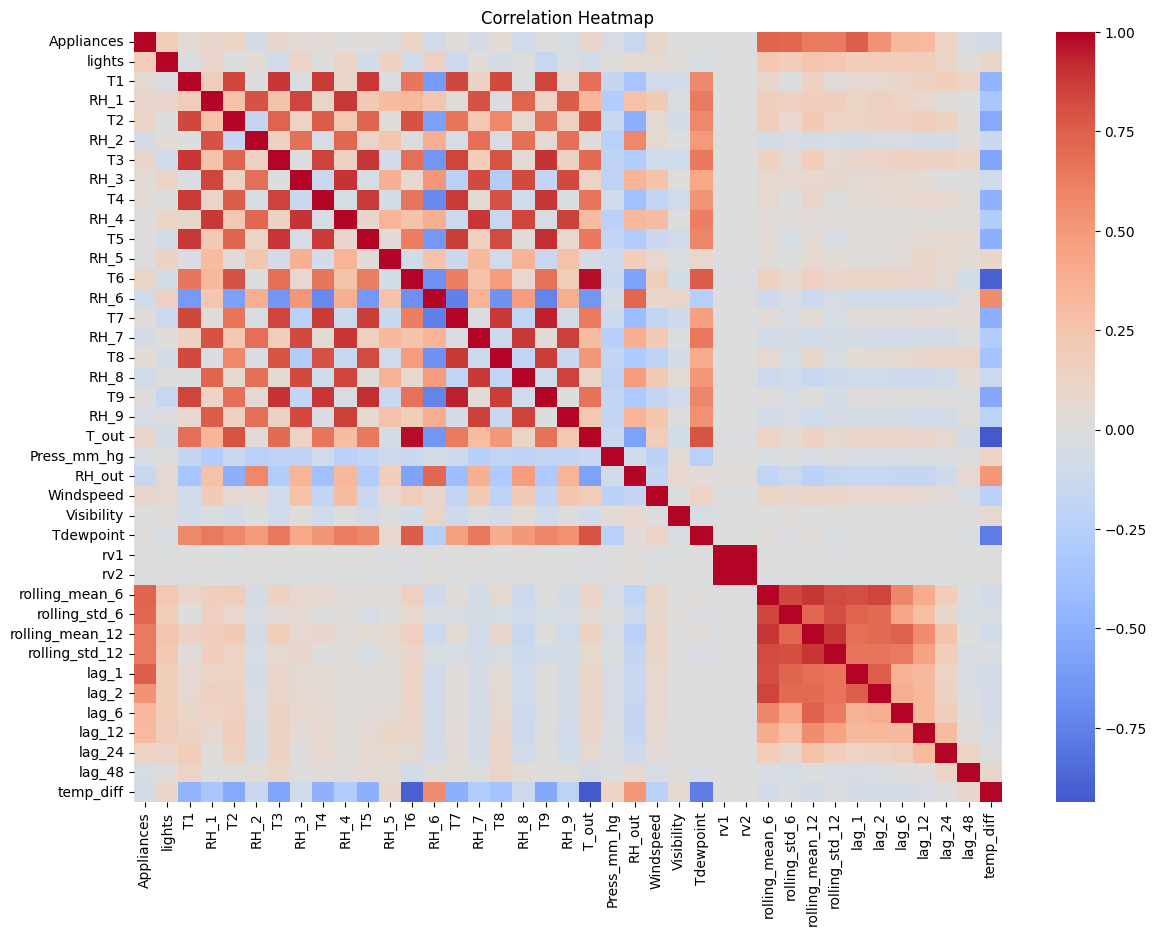

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# Correlation with target
corr_target = corr_matrix['Appliances'].sort_values(ascending=False)

corr_target

Appliances         1.000000
lag_1              0.753116
rolling_mean_6     0.729965
rolling_std_6      0.715069
rolling_std_12     0.637916
rolling_mean_12    0.635958
lag_2              0.534881
lag_6              0.325866
lag_12             0.312363
lights             0.196113
T2                 0.120073
T6                 0.117915
lag_24             0.114970
T_out              0.099399
Windspeed          0.086802
RH_1               0.086698
T3                 0.085730
T1                 0.055274
T4                 0.040665
T8                 0.040275
RH_3               0.036392
T7                 0.026178
T5                 0.020022
RH_4               0.016506
Tdewpoint          0.015352
T9                 0.010390
RH_5               0.006359
Visibility         0.000072
rv2               -0.010670
rv1               -0.010670
Press_mm_hg       -0.034517
lag_48            -0.040468
RH_9              -0.051116
RH_7              -0.056358
RH_2              -0.060857
temp_diff         -0

###  Interpretation of Correlation

The correlation values indicate how strongly each feature is linearly related to energy consumption.

- Features with high positive correlation increase energy usage.
- Features with negative correlation indicate inverse relationships.
- Lag features (e.g., `lag_1`, `lag_6`) typically show strong correlation, confirming temporal dependency.
- Time-based features may show moderate correlation, reflecting daily usage patterns.

However, correlation only captures **linear relationships** and may miss more complex dependencies.

##  Mutual Information Analysis

Mutual Information (MI) measures **any type of relationship** (linear or non-linear) between features and the target variable.

Higher MI score → More informative feature

In [30]:
from sklearn.feature_selection import mutual_info_regression

# Features and target
X = df_numeric.drop(columns=['Appliances'])
y = df_numeric['Appliances']

mi_scores = mutual_info_regression(X, y)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

mi_series

lag_1              0.721951
rolling_mean_6     0.714740
lag_2              0.546300
rolling_mean_12    0.521703
rolling_std_6      0.375497
rolling_std_12     0.368336
lag_6              0.283430
lag_12             0.167014
T9                 0.132713
T5                 0.116166
T7                 0.111432
T3                 0.110421
T8                 0.110250
T4                 0.106367
RH_6               0.104665
T1                 0.101684
RH_1               0.090578
T6                 0.089815
T2                 0.088907
RH_8               0.083678
Press_mm_hg        0.079431
RH_5               0.077289
RH_4               0.077089
T_out              0.072580
RH_9               0.070807
RH_3               0.069017
RH_7               0.067224
RH_2               0.064124
lag_24             0.061432
RH_out             0.053255
lights             0.052294
Tdewpoint          0.043134
temp_diff          0.039613
Visibility         0.030258
Windspeed          0.024970
lag_48             0

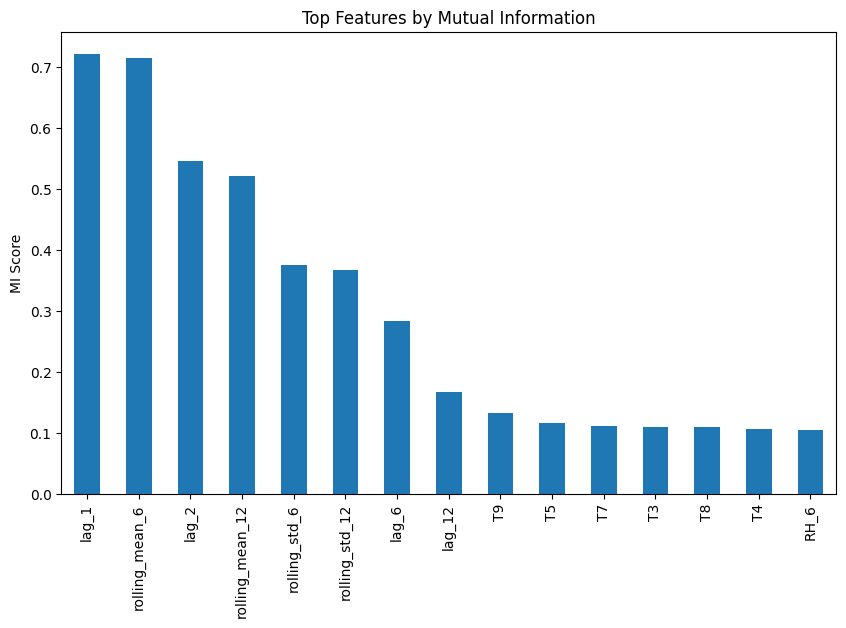

In [31]:
plt.figure(figsize=(10,6))
mi_series.head(15).plot(kind='bar')
plt.title("Top Features by Mutual Information")
plt.ylabel("MI Score")
plt.show()

###  Interpretation of Mutual Information

Mutual Information reveals both linear and non-linear dependencies between features and energy consumption.

- Lag features usually rank high, confirming their importance.
- Interaction features like `temp_diff` may show higher importance here compared to correlation.
- Fourier features may also appear more relevant due to capturing cyclical patterns.

Unlike correlation, MI can detect hidden relationships that are not strictly linear.